# Notebook For Analysis

# Setup

In [1]:
!echo $HOSTNAME
!python --version
!nvidia-smi

c009
Python 3.12.5
/bin/bash: line 1: nvidia-smi: command not found


In [2]:
# General Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import einops
from fancy_einsum import einsum
import os
import sys
import tqdm.auto as tqdm
import random
from pathlib import Path
import plotly.express as px
import copy

from typing import List, Union, Optional
from functools import partial
import itertools
from IPython.display import HTML

# CSV Use Libraries
import pandas as pd

# Function Imports
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Unused
# from torch.utils.data import DataLoader
# from transformers import AutoModelForCausalLM, AutoConfig, AutoTokenizer
# import dataclasses
# import datasets
# import ast
# from transformers import get_cosine_schedule_with_warmup #Used for lr?
# from torch.nn.utils import clip_grad_norm_

In [3]:
from config import *

# Shared helpers from Transformer.py
from Transformer import (
    setup_device, 
    build_model, 
    load_train_test_data, 
    load_checkpoint_into,
    descent_loss_fn, 
    descent_accuracy_fn, 
    descent_sequence_accuracy,
    mask_even_indices_mask as create_attention_mask,  # <--- Aliased cleanly here!
    register_pad_mask_hook,
)

## Define Graphing Functs

In [4]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"
print(f"Using renderer: {pio.renderers.default}")

Using renderer: notebook_connected


In [5]:
pio.templates['plotly'].layout.xaxis.title.font.size = 20
pio.templates['plotly'].layout.yaxis.title.font.size = 20
pio.templates['plotly'].layout.title.font.size = 30

In [6]:
import transformer_lens
import transformer_lens.utilities as utils
from transformer_lens import HookedTransformer

# Unpickling shim: checkpoints pickled by other transformer_lens versions may reference
# the config class through the old top-level module path. Alias it if this version
# provides the new path; skip silently if the layout changes again.
try:
    import transformer_lens.config.hooked_transformer_config as htc
    sys.modules.setdefault('transformer_lens.HookedTransformerConfig', htc)
except ImportError:
    pass

In [7]:
# Unused plotting functions in favor of Neel Plotly

# def imshow(tensor, renderer=None, xaxis="", yaxis="", **kwargs):
#     px.imshow(utils.to_numpy(tensor), color_continuous_midpoint=0.0, color_continuous_scale="RdBu", labels={"x":xaxis, "y":yaxis}, **kwargs).show(renderer)

# def line(tensor, renderer=None, xaxis="", yaxis="", **kwargs):
#     px.line(utils.to_numpy(tensor), labels={"x":xaxis, "y":yaxis}, **kwargs).show(renderer)

# def scatter(x, y, xaxis="", yaxis="", caxis="", renderer=None, **kwargs):
#     x = utils.to_numpy(x)
#     y = utils.to_numpy(y)
#     px.scatter(y=y, x=x, labels={"x":xaxis, "y":yaxis, "color":caxis}, **kwargs).show(renderer)

## Set Paths and GPU Devices

In [8]:
# PTH_LOCATION is imported from config.py; create the directory if it doesn't exist yet
# DATA_PATH and PTH_LOCATION are now resolved from config.py
os.makedirs(Path(PTH_LOCATION).parent, exist_ok=True)
print(f"Data Dir:  {DATA_PATH}")
print(f"Model PTH: {PTH_LOCATION}")

Data Dir:  /home/katyala/CoxeterArtinProject/transformer/2026/Ryan_Code_RightDescent_Even_Indices_Masked
Model PTH: /home/katyala/CoxeterArtinProject/transformer/2026/Ryan_Code_RightDescent_Even_Indices_Masked/workspace/_scratch/model.pth


In [9]:
device, device1 = setup_device()

CUDA available: False
Device count: 0
Device Name: cpu


## Define Model and Optimizer Params

In [10]:
import torch

# 1. Set seeds for reproducibility
torch.manual_seed(seed=DATA_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(DATA_SEED)

# 2. Determine available device dynamically
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Load the checkpoint safely onto the current device
cached_data = torch.load(PTH_LOCATION, map_location=device, weights_only=False)
cfg = cached_data["config"]

# Force TransformerLens to initialize modules on the current device
cfg.device = str(device)

# 4. Reconstruct the model, optimizer, and scheduler structure
model, optimizer, scheduler = build_model(cfg)

# 5. Move the model to the active device
model.to(device)

# 6. Fill in the trained weights and optimizer state from the memory-loaded dictionary
model.load_state_dict(cached_data["model"])
optimizer.load_state_dict(cached_data["optimizer"])

if "scheduler" in cached_data and scheduler is not None:
    scheduler.load_state_dict(cached_data["scheduler"])

# 7. Unpack historical training telemetry directly from cached_data
model_checkpoints    = cached_data["checkpoints"]
checkpoint_epochs    = cached_data["checkpoint_epochs"]
train_losses         = cached_data["train_losses"]
test_losses          = cached_data["test_losses"]
train_accuracies     = cached_data["train_accuracies"]
test_accuracies      = cached_data["test_accuracies"]
train_bit_accuracies = cached_data["train_bit_accuracies"]
test_bit_accuracies  = cached_data["test_bit_accuracies"]

Moving model to device:  cpu


## Misc Setup
Loss/accuracy/masking functions are imported from `Transformer.py` at the top.

In [11]:
torch.cuda.empty_cache()
clsDex = SEQUENCE_LENGTH - 1 # index of classification token, kept for attention pattern analysis

## Initialize Datasets

In [12]:
# Load the pre-split train/test CSVs (TRAIN_CSV / TEST_CSV) and move to device —
# the same fixed partition the training script used.
data = load_train_test_data(device1)
train_tokens,  test_tokens  = data["train_tokens"],  data["test_tokens"]
train_targets, test_targets = data["train_targets"], data["test_targets"]
train_mask,    test_mask    = data["train_mask"],    data["test_mask"]
train_attention_mask = data["train_attention_mask"]
test_attention_mask  = data["test_attention_mask"]

Loaded dataset: tokens (599, 36) | targets (599, 36, 3)
Loaded dataset: tokens (1399, 36) | targets (1399, 36, 3)


# Graph Results

In [13]:
from neel_plotly.plot import line_or_scatter, line as neel_line

In [14]:
print(CHECKPOINT_STEP)
skipBy = 1


def createGraph(yTrain, yTest, yName, title):
    fig = line_or_scatter(
        [yTrain[::skipBy], yTest[::skipBy]],
        x=np.arange(0, len(yTrain), skipBy),
        xaxis="Epoch",
        yaxis=yName,
        log_y=True,
        title=title,
        line_labels=['train', 'test'],
        toggle_x=True,
        toggle_y=True,
        plot_type="line",
        return_fig=True
    )
    return fig

fig1 = createGraph(train_losses, test_losses, "Loss", "Loss Curve for Word Problem")
fig2 = createGraph(train_accuracies, test_accuracies, "Accuracy", "Accuracy Curve for Word Problem")
fig3 = createGraph(train_bit_accuracies, test_bit_accuracies, "Per Bit Accuracy", "Per Bit Accuracy Curve for Word Problem")


fig1.show()
fig2.show()
fig3.show()


fig1.write_html("1. loss_curve.html")
fig2.write_html("2. accuracy_curve.html")
fig3.write_html("3. bit_accuracy.html")


100


# Analysing the Model

Helpful Memory Probing Functions:

- nvidia-smi
- torch.cuda.empty_cache()
- torch.set_grad_enabled(mode=False)
- gc.collect()
- print(torch.cuda.memory_summary())
- torch profiler also (saved image on Aug 03, 2025 ~6pm)

### Helper Functions
- logit return function
- prediction function

In [15]:
import gc

def getLogits(model: HookedTransformer, tokens, getCache: bool = False):
    """
    Applies the padding/attention mask and runs a forward pass.
    Returns detached logits (and optionally the activation cache).
    """
    with torch.inference_mode():
        # 1. Generate mask from the tokens passed in
        mask = create_attention_mask(tokens).to(tokens.device)

        # 2. Define hook that dynamically matches attn_scores dimensions
        def mask_attn_scores(attn_scores, hook):
            # attn_scores shape: [batch, num_heads, q_pos, k_pos]
            q_pos = attn_scores.shape[-2]
            k_pos = attn_scores.shape[-1]
            batch_sz = attn_scores.shape[0]

            m = mask.to(attn_scores.device)

            # Slice mask to match the current query/key sequence lengths
            if m.ndim == 2:
                # [seq_len, seq_len] -> slice to [q_pos, k_pos] -> [1, 1, q_pos, k_pos]
                m_sliced = m[:q_pos, :k_pos].unsqueeze(0).unsqueeze(0)
            elif m.ndim == 3:
                # [batch, seq_len, seq_len] -> slice to [batch, 1, q_pos, k_pos]
                m_sliced = m[:batch_sz, :q_pos, :k_pos].unsqueeze(1)
            else:
                m_sliced = m

            # Mask out invalid key positions with -inf
            return attn_scores.masked_fill(~m_sliced.bool(), float('-inf'))

        # 3. Register hooks across all layers
        fwd_hooks = [
            (f"blocks.{layer}.attn.hook_attn_scores", mask_attn_scores)
            for layer in range(model.cfg.n_layers)
        ]

        # 4. Run model inside hook context manager
        with model.hooks(fwd_hooks=fwd_hooks):
            if getCache:
                original_logits_og, cache = model.run_with_cache(tokens)
            else:
                original_logits_og = model(tokens)
                cache = None

        original_logits = original_logits_og.detach().clone()

    del original_logits_og, mask
    torch.cuda.empty_cache()

    if getCache:
        return original_logits, cache
    else:
        return original_logits
        
def getPredictions(model: HookedTransformer, tokens, targets, mask):
    """
    Per-sequence descent accuracy: fraction of prefixes whose descent set is
    exactly correct. Shape: (batch_size,)
    """
    logits  = getLogits(model, tokens, getCache=False)
    seq_acc = descent_sequence_accuracy(logits, targets, mask)
    del logits
    return seq_acc

def imshow(tensor, renderer=None, xaxis="", yaxis="", xlabels=None, ylabels=None, aspect="auto", **kwargs):
    fig = px.imshow(
        utils.to_numpy(tensor),
        color_continuous_midpoint=0.0,
        color_continuous_scale="RdBu",
        labels={"x": xaxis, "y": yaxis},
        aspect=aspect,
        **kwargs
    )
    if xlabels is not None:
        fig.update_xaxes(tickmode='array', tickvals=list(range(len(xlabels))), ticktext=xlabels)
    if ylabels is not None:
        fig.update_yaxes(tickmode='array', tickvals=list(range(len(ylabels))), ticktext=ylabels)
    fig.update_yaxes(scaleanchor=None)
    fig.show(renderer)
    return fig

def cleanup():
    gc.collect()
    torch.cuda.empty_cache()

## Quick Analysis + Memory Cleanup

In [16]:
torch.set_grad_enabled(False)
gc.collect()
torch.cuda.empty_cache()

In [17]:
original_logits, cache = getLogits(model, train_tokens, getCache=True)

Get key weight matrices:

In [18]:
W_E = model.embed.W_E[:-1]
print("W_E", W_E.shape)
W_neur = W_E @ model.blocks[0].attn.W_V @ model.blocks[0].attn.W_O @ model.blocks[0].mlp.W_in
print("W_neur", W_neur.shape)
W_logit = model.blocks[0].mlp.W_out @ model.unembed.W_U
print("W_logit", W_logit.shape)

W_E torch.Size([3, 256])
W_neur torch.Size([4, 3, 1024])
W_logit torch.Size([1024, 3])


In [19]:
original_loss = descent_loss_fn(original_logits, train_targets, train_mask).item()
print("Original Loss:", original_loss)

Original Loss: 19.23977279663086


### Looking at Activations

Get all shapes:

In [20]:
for param_name, param in cache.items():
    print(param_name, param.shape)

hook_embed torch.Size([599, 36, 256])
hook_pos_embed torch.Size([599, 36, 256])
blocks.0.hook_resid_pre torch.Size([599, 36, 256])
blocks.0.attn.hook_q torch.Size([599, 36, 4, 64])
blocks.0.attn.hook_k torch.Size([599, 36, 4, 64])
blocks.0.attn.hook_v torch.Size([599, 36, 4, 64])
blocks.0.attn.hook_attn_scores torch.Size([599, 4, 36, 36])
blocks.0.attn.hook_pattern torch.Size([599, 4, 36, 36])
blocks.0.attn.hook_z torch.Size([599, 36, 4, 64])
blocks.0.hook_attn_out torch.Size([599, 36, 256])
blocks.0.hook_resid_mid torch.Size([599, 36, 256])
blocks.0.mlp.hook_pre torch.Size([599, 36, 1024])
blocks.0.mlp.hook_post torch.Size([599, 36, 1024])
blocks.0.hook_mlp_out torch.Size([599, 36, 256])
blocks.0.hook_resid_post torch.Size([599, 36, 256])
blocks.1.hook_resid_pre torch.Size([599, 36, 256])
blocks.1.attn.hook_q torch.Size([599, 36, 4, 64])
blocks.1.attn.hook_k torch.Size([599, 36, 4, 64])
blocks.1.attn.hook_v torch.Size([599, 36, 4, 64])
blocks.1.attn.hook_attn_scores torch.Size([599, 4

In [21]:
# print(model)

# debug: prints the first 4 input train data values
# print(train_tokens[:4])

# Embedding matrix W_E: [d_vocab, d_model] = (4, 256) — 3 generators + the padding token.
# The last row is the padding token's embedding; [:-1] drops it.
# print(model.embed.W_E.shape)
# print(model.embed.W_E)
# print(model.embed.W_E[:-1])

# Embedding a batch of tokens: [batch, seq_len] -> [batch, seq_len, d_model]
# print(train_tokens.shape)
# print(model.embed(train_tokens).shape)

## Attention Heads (average)

### Average attention over all words for each head
Note: all train data input words used and averaged out for these graphs
- x: letters (keys attended to)
- y: letters (query giving attention to x axis)

In [24]:
n_heads = model.cfg.n_heads
seq_len = model.cfg.n_ctx
str_tokens = [str(i) for i in range(seq_len)]

with torch.inference_mode():
    for layer in range(model.cfg.n_layers):
        head_sums  = None   # reset per layer
        num_samples = 0

        for wordIndex in range(len(train_tokens)):
            # Grab attention pattern: [n_heads, seq_len, seq_len]
            attn_patterns = cache["pattern", layer][wordIndex]

            if head_sums is None:
                head_sums = torch.zeros_like(attn_patterns)

            head_sums   += attn_patterns
            num_samples += 1

        # Average attention
        avg_attn = head_sums / num_samples

        for head in range(n_heads):
            imshow(
                avg_attn[head].detach().cpu(),
                x=str_tokens,
                y=str_tokens,
                xaxis="Key (Attended To)",
                yaxis="Query (Paying Attention)",
                title=f"Layer {layer} Head {head} — Average Attention Across Dataset",
                aspect=None,
            )

### Average Attention Pattern over Attention Heads

In [25]:
for layer in range(model.cfg.n_layers):
    attention = cache["pattern", layer].mean(dim=0)[:, clsDex, :]
    imshow(
        attention,
        title=f"Average Attention Paid | for token {clsDex} | per head | layer {layer}",
        xaxis="Source",
        yaxis="Head",
        x=[str(i) for i in range(train_tokens.shape[1])],
        ylabels=[f"{i}" for i in range(attention.shape[0])]
    )

## Attention Heads (word: X)

In [26]:
# Look at a specific word in the dataset by its (shuffled) index
wordIndex = 151

# Evaluate the model on a single word
wordTensor  = train_tokens[wordIndex]
wordTokens  = wordTensor.unsqueeze(0)                  # add batch dimension
wordTargets = train_targets[wordIndex].unsqueeze(0)
wordMask    = train_mask[wordIndex].unsqueeze(0)
seq_acc = getPredictions(model, wordTokens, wordTargets, wordMask)

logits = getLogits(model, wordTokens, getCache=False)
probs = torch.sigmoid(logits)
preds = (probs > 0.5).int()

print("Word:    ", end="")
for i in range(len(wordTensor)):
    print("a", end="") if wordTensor[i] == 1 else None
    print("b", end="") if wordTensor[i] == 2 else None
    print("c", end="") if wordTensor[i] == 3 else None
print()

for t in range(wordTokens.shape[1]):
    true_labels = wordTargets[0, t].int().tolist()
    pred_labels = preds[0, t].tolist()

    print(f"{t:02d}  True: {true_labels}   Pred: {pred_labels}   Correct:{true_labels == pred_labels}")

print(f"Seq Acc: {seq_acc.item():.4f}  (fraction of prefixes with an exactly-correct descent set)")

Word:    abacabacabacabacabacabacabcabcabcabc
00  True: [1, 0, 0]   Pred: [1, 0, 0]   Correct:True
01  True: [0, 1, 0]   Pred: [0, 1, 0]   Correct:True
02  True: [1, 1, 0]   Pred: [1, 0, 0]   Correct:False
03  True: [0, 0, 1]   Pred: [0, 1, 0]   Correct:False
04  True: [1, 0, 1]   Pred: [1, 0, 0]   Correct:False
05  True: [0, 1, 0]   Pred: [0, 1, 0]   Correct:True
06  True: [1, 1, 0]   Pred: [1, 0, 0]   Correct:False
07  True: [0, 0, 1]   Pred: [0, 1, 0]   Correct:False
08  True: [1, 0, 1]   Pred: [1, 0, 0]   Correct:False
09  True: [0, 1, 0]   Pred: [0, 1, 0]   Correct:True
10  True: [1, 1, 0]   Pred: [1, 0, 0]   Correct:False
11  True: [0, 0, 1]   Pred: [0, 1, 0]   Correct:False
12  True: [1, 0, 1]   Pred: [1, 0, 0]   Correct:False
13  True: [0, 1, 0]   Pred: [0, 1, 0]   Correct:True
14  True: [1, 1, 0]   Pred: [1, 0, 0]   Correct:False
15  True: [0, 0, 1]   Pred: [0, 1, 1]   Correct:False
16  True: [1, 0, 1]   Pred: [1, 0, 0]   Correct:False
17  True: [0, 1, 0]   Pred: [0, 1, 0]   C

In [27]:
# Look at a specific word in the dataset by its (shuffled) index
testIndex = 1134

# Evaluate the model on a single word
wordTensor  = test_tokens[testIndex]
wordTokens  = wordTensor.unsqueeze(0)                  # add batch dimension
wordTargets = test_targets[testIndex].unsqueeze(0)
wordMask    = test_mask[testIndex].unsqueeze(0)
seq_acc = getPredictions(model, wordTokens, wordTargets, wordMask)

logits = getLogits(model, wordTokens, getCache=False)
probs = torch.sigmoid(logits)
preds = (probs > 0.5).int()

print("Word:    ", end="")
for i in range(len(wordTensor)):
    print("a", end="") if wordTensor[i] == 1 else None
    print("b", end="") if wordTensor[i] == 2 else None
    print("c", end="") if wordTensor[i] == 3 else None
print()

for t in range(wordTokens.shape[1]):
    true_labels = wordTargets[0, t].int().tolist()
    pred_labels = preds[0, t].tolist()

    print(f"{t:02d}  True: {true_labels}   Pred: {pred_labels}   Correct:{true_labels == pred_labels}")

print(f"Seq Acc: {seq_acc.item():.4f}  (fraction of prefixes with an exactly-correct descent set)")

Word:    bacabacabacabacabacabacbacbacbacbac
00  True: [0, 1, 0]   Pred: [0, 1, 0]   Correct:True
01  True: [1, 0, 0]   Pred: [1, 0, 0]   Correct:True
02  True: [0, 0, 1]   Pred: [0, 0, 1]   Correct:True
03  True: [1, 0, 1]   Pred: [1, 0, 0]   Correct:False
04  True: [0, 1, 0]   Pred: [1, 1, 0]   Correct:False
05  True: [1, 1, 0]   Pred: [1, 0, 0]   Correct:False
06  True: [0, 0, 1]   Pred: [0, 0, 1]   Correct:True
07  True: [1, 0, 1]   Pred: [1, 0, 0]   Correct:False
08  True: [0, 1, 0]   Pred: [1, 1, 0]   Correct:False
09  True: [1, 1, 0]   Pred: [1, 0, 0]   Correct:False
10  True: [0, 0, 1]   Pred: [1, 0, 1]   Correct:False
11  True: [1, 0, 1]   Pred: [1, 0, 0]   Correct:False
12  True: [0, 1, 0]   Pred: [1, 1, 0]   Correct:False
13  True: [1, 1, 0]   Pred: [1, 0, 0]   Correct:False
14  True: [0, 0, 1]   Pred: [1, 0, 1]   Correct:False
15  True: [1, 0, 1]   Pred: [1, 0, 0]   Correct:False
16  True: [0, 1, 0]   Pred: [1, 1, 0]   Correct:False
17  True: [1, 1, 0]   Pred: [1, 0, 0]   C

### Attention patterns per each head on ONE word
- prints 4 graphs

In [28]:
# Prints 1 graph per attention head
# x: letters (keys attended to)
# y: letters (query giving attention to x axis)


# Move to test device, because it has more memory
chosenWord = train_tokens[wordIndex].unsqueeze(0).to(device1)  # shape (1, 22)
print(chosenWord)


# Generate labeled tokens with position

# ex: word len 22: str_tokens = [0,...,21]
str_tokens = [f"{i}" for i, tok in enumerate(chosenWord[0])]

# Visualize
n_heads = model.cfg.n_heads
n_layers = model.cfg.n_layers
for layer in range(n_layers):
    for head in range(n_heads):
        # gets the attention pattern for layer 0, pick 1 word from the batch and look at 1 head for it
        # detatch tensor from computation graph (no gradients), move tensor to cpu to make imshow heatmap
        attn_single_head = cache["pattern", layer][wordIndex, head].detach().cpu()
        imshow(
            attn_single_head,
            x=str_tokens,
            y=str_tokens,
            xaxis="Key (Attended To)",
            yaxis="Query (Paying Attention)",
            title=f"Layer {layer} Head {head} Attention Pattern (Positional Tokens)",
            aspect=None
        )


tensor([[1, 2, 1, 3, 1, 2, 1, 3, 1, 2, 1, 3, 1, 2, 1, 3, 1, 2, 1, 3, 1, 2, 1, 3,
         1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3]])


### Attention Pattern for wordIndex over attention Heads

In [29]:
# Attention pattern for a specific word (x: generators, y: attention heads)
# Assuming train_tokens is shape (batch, seq_len), and you're using batch 0?

token_strs = [str(x) for x in chosenWord.squeeze(0).tolist()]

for layer in range(model.cfg.n_layers):
    attention = cache["pattern", layer][wordIndex][:, clsDex, :]
    imshow(
        attention,
        title=f"Attention Pattern (for word {wordIndex}) over Attention Heads in layer {layer}",
        xaxis="Source",
        yaxis="Head",
        #x=[str(i) for i in range(train_tokens.shape[1])],
        xlabels=token_strs,
        ylabels=[f"{i}" for i in range(attention.shape[0])]
    )

print([str(i) for i in range(train_tokens.shape[1])])
print(token_strs)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35']
['1', '2', '1', '3', '1', '2', '1', '3', '1', '2', '1', '3', '1', '2', '1', '3', '1', '2', '1', '3', '1', '2', '1', '3', '1', '2', '3', '1', '2', '3', '1', '2', '3', '1', '2', '3']


In [30]:
# Move to test device, because it has more memory
# Assuming train_tokens has shape (batch_size, seq_len)
chosenWord = train_tokens.to(device1)  
print(f"Processing batch of shape: {chosenWord.shape}")

# Generate labeled tokens with position based on the sequence length
seq_len = chosenWord.shape[1]
str_tokens = [f"{i}" for i in range(seq_len)]

# Visualize
n_heads = model.cfg.n_heads
n_layers = model.cfg.n_layers

for layer in range(n_layers):
    for head in range(n_heads):
        # 1. Fetch the pattern tensor for this layer. Shape: (batch_size, n_heads, seq_len, seq_len)
        # 2. Select the specific head. Shape: (batch_size, seq_len, seq_len)
        # 3. Take the mean along the batch dimension (dim=0) to average over all words.
        # 4. Detach and move to CPU for plotting.
        avg_attn_single_head = cache["pattern", layer][:, head].mean(dim=0).detach().cpu()
        
        imshow(
            avg_attn_single_head,
            x=str_tokens,
            y=str_tokens,
            xaxis="Key (Attended To)",
            yaxis="Query (Paying Attention)",
            title=f"Layer {layer} Head {head} AVERAGE Attention Pattern (All Words)",
            aspect=None
        )

Processing batch of shape: torch.Size([599, 36])


## Misclassification Graphs
- Counting how many times the model predicts an incorrect descent set at each token index (position). With causal masking each index is an independent prediction over its prefix.

In [31]:
# Move to test device, because it has more memory
# Assuming train_tokens has shape (batch_size, seq_len)
chosenWord = train_tokens.to(device1)  
print(f"Processing batch of shape: {chosenWord.shape}")

# Generate labeled tokens with position based on the sequence length
seq_len = chosenWord.shape[1]
str_tokens = [f"{i}" for i in range(seq_len)]

# Visualize
n_heads = model.cfg.n_heads
n_layers = model.cfg.n_layers

for layer in range(n_layers):
    for head in range(n_heads):
        # 1. Fetch the pattern tensor for this layer. Shape: (batch_size, n_heads, seq_len, seq_len)
        # 2. Select the specific head. Shape: (batch_size, seq_len, seq_len)
        # 3. Take the mean along the batch dimension (dim=0) to average over all words.
        # 4. Detach and move to CPU for plotting.
        avg_attn_single_head = cache["pattern", layer][:, head].mean(dim=0).detach().cpu()
        
        imshow(
            avg_attn_single_head,
            x=str_tokens,
            y=str_tokens,
            xaxis="Key (Attended To)",
            yaxis="Query (Paying Attention)",
            title=f"Layer {layer} Head {head} AVERAGE Attention Pattern (All Words)",
            aspect=None
        )

Processing batch of shape: torch.Size([599, 36])


### Train Misclassification Graphs:

In [32]:
from collections import defaultdict
import matplotlib.pyplot as plt


def position_error_counts(model, tokens, targets, mask):
    """
    Per-token-index misclassification counts.

    With causal masking, the prediction at index i depends only on the prefix
    s_1..s_i, so "token index" i is a well-defined position. A position counts as
    incorrect when its predicted descent set differs from the target in any
    generator bit (same exact-set criterion as descent_accuracy_fn). Padding
    positions (mask == 0) are excluded.

    Returns (incorrect_per_pos, total_per_pos), each shape (seq_len,) on CPU.
    """
    logits = getLogits(model, tokens, getCache=False)        # [B, S, n_gen]
    preds  = (logits > 0).float()
    correct_bits = (preds == targets).float().sum(dim=-1)    # [B, S]
    exact  = (correct_bits == logits.size(-1)).float()       # [B, S] 1 = all bits right
    m = mask.float()                                         # [B, S]
    incorrect_per_pos = ((1.0 - exact) * m).sum(dim=0)       # [S]
    total_per_pos     = m.sum(dim=0)                         # [S]
    del logits
    return incorrect_per_pos.cpu(), total_per_pos.cpu()


# --- Per-sequence stats (still used by the sampling + "Other Graphs" cells) ---
words = []
seq_accuracies = []
lengths = []
dataset_indices = []

total_by_length         = defaultdict(int)
misclassified_by_length = defaultdict(int)

# Per-sequence descent accuracy for all train examples (1.0 = every prefix's descent set correct)
train_seq_acc = getPredictions(model, train_tokens, train_targets, train_mask)

for i in range(len(train_tokens)):
    input_seq = train_tokens[i]
    word_str  = ' '.join([str(int(tok)) for tok in input_seq.tolist()])
    word_len  = (input_seq != 0).sum().item()   # no special token in the new format

    words.append(word_str)
    seq_accuracies.append(train_seq_acc[i].item())
    lengths.append(word_len)
    dataset_indices.append(i)

    total_by_length[word_len] += 1
    if train_seq_acc[i].item() < 1.0:
        misclassified_by_length[word_len] += 1

# --- Per-token-index error counts (the misclassification-by-position view) ---
train_incorrect, train_total = position_error_counts(model, train_tokens, train_targets, train_mask)
print("Train incorrect predictions per token index:")
print(train_incorrect.int().tolist())
print(f"Total incorrect positions: {int(train_incorrect.sum())} / {int(train_total.sum())} valid positions")

Train incorrect predictions per token index:
[0, 199, 0, 413, 0, 397, 0, 383, 0, 222, 0, 466, 0, 190, 0, 319, 0, 280, 0, 282, 0, 209, 0, 228, 0, 147, 0, 137, 0, 123, 0, 80, 0, 49, 0, 29]
Total incorrect positions: 4153 / 7151 valid positions



Random Sample of Misclassified Train Sequences:
Word: 1 2 1 3 1 2 3 1 2 3 1 2 3 1 2 3 1 2 3 1 2 3 1 2 0 0 0 0 0 0 0 0 0 0 0 0 | Length: 24 | Seq Acc: 0.417 | Index: 359
Word: 1 2 3 1 2 1 3 1 2 1 3 1 2 3 1 2 3 1 2 3 1 2 3 0 0 0 0 0 0 0 0 0 0 0 0 0 | Length: 23 | Seq Acc: 0.455 | Index: 298
Word: 1 3 1 2 1 3 1 2 1 3 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 | Length: 12 | Seq Acc: 0.667 | Index: 504
Word: 3 1 2 1 3 1 2 3 1 2 3 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 | Length: 12 | Seq Acc: 0.333 | Index: 466
Word: 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 3 1 2 3 1 2 3 0 0 0 0 0 | Length: 31 | Seq Acc: 0.733 | Index: 123
Word: 1 2 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 | Length: 20 | Seq Acc: 0.500 | Index: 557
Word: 2 3 1 2 1 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 | Length: 6 | Seq Acc: 0.333 | Index: 400
Word: 3 1 2 1 3 1 2 1 3 2 1 3 2 1 3 2 1 3 2 1 3 2 1 3 2 1 0 0 0 0 0 0 0 0 0 0 | Length: 26 | Seq Acc: 0.0

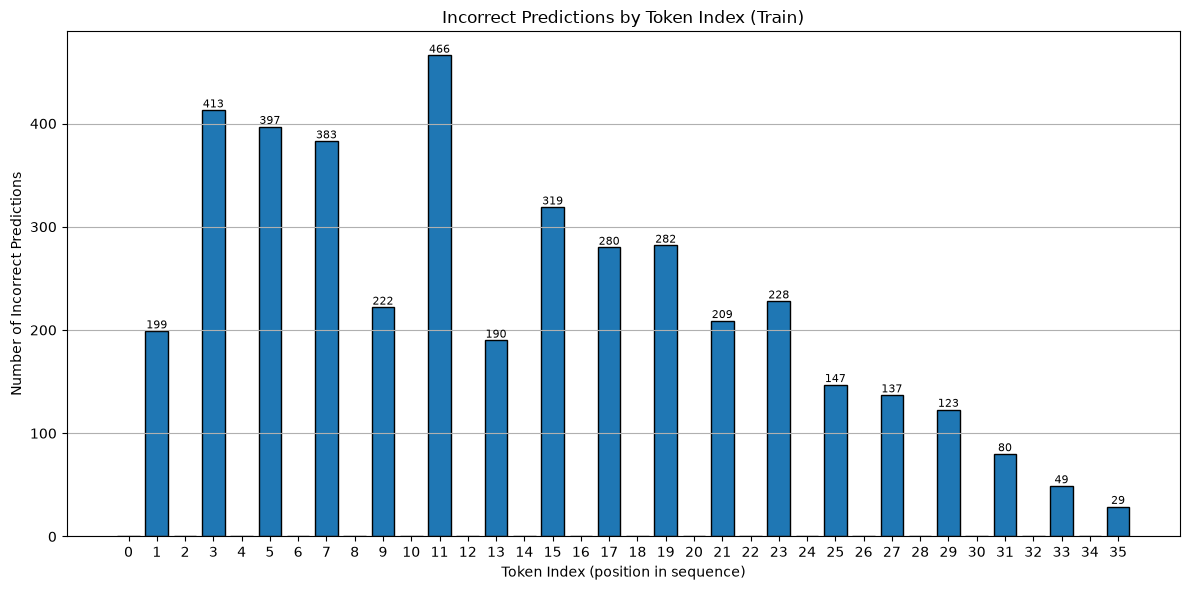

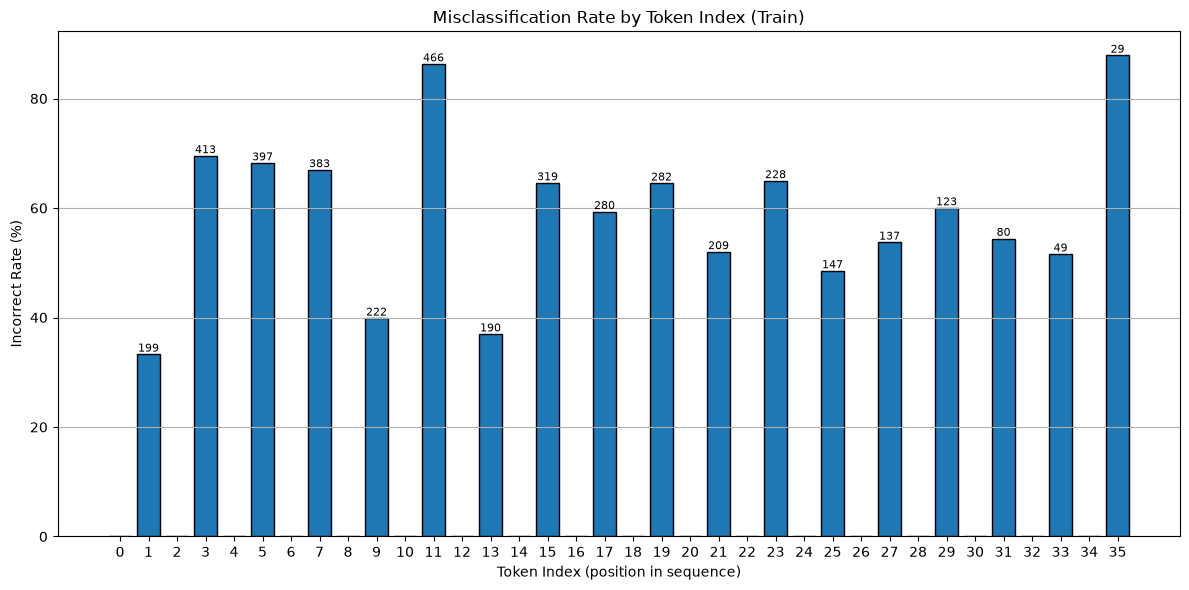

In [33]:
# Per-sequence misclassified list (used by the attention-head visualization below)
misclassified = [
    (words[i], lengths[i], seq_accuracies[i], dataset_indices[i])
    for i in range(len(words)) if seq_accuracies[i] < 1.0
]

print("\nRandom Sample of Misclassified Train Sequences:")
for word, length, acc, idx in random.sample(misclassified, min(20, len(misclassified))):
    print(f"Word: {word} | Length: {length} | Seq Acc: {acc:.3f} | Index: {idx}")

positions = list(range(len(train_incorrect)))
counts    = train_incorrect.int().tolist()

# Plot 1: Raw count of incorrect predictions at each token index
plt.figure(figsize=(12, 6))
bars = plt.bar(positions, counts, edgecolor='black')
for bar, c in zip(bars, counts):
    if c > 0:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 str(c), ha='center', va='bottom', fontsize=8)
plt.title("Incorrect Predictions by Token Index (Train)")
plt.xlabel("Token Index (position in sequence)")
plt.ylabel("Number of Incorrect Predictions")
plt.xticks(positions)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# Plot 2: Misclassification rate at each token index (relative to valid positions there)
percent = [100 * i / t if t > 0 else 0.0
           for i, t in zip(train_incorrect.tolist(), train_total.tolist())]
plt.figure(figsize=(12, 6))
bars = plt.bar(positions, percent, edgecolor='black')
for bar, c in zip(bars, counts):
    if c > 0:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 str(c), ha='center', va='bottom', fontsize=8)
plt.title("Misclassification Rate by Token Index (Train)")
plt.xlabel("Token Index (position in sequence)")
plt.ylabel("Incorrect Rate (%)")
plt.xticks(positions)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

### Test Misclassification Graphs


Random Sample of Misclassified Test Sequences:
Word: 3 2 1 3 2 1 3 2 1 3 2 1 3 2 1 3 2 1 3 2 1 3 2 1 3 2 1 3 2 1 3 2 1 3 2 0 | Length: 35 | Seq Acc: 0.588 | Index: 583
Word: 1 2 1 3 1 2 1 3 1 2 1 3 1 2 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 | Length: 15 | Seq Acc: 0.571 | Index: 123
Word: 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 0 0 0 0 0 0 0 0 0 0 0 | Length: 25 | Seq Acc: 0.667 | Index: 1289
Word: 1 3 1 2 1 3 1 2 3 1 2 3 1 2 3 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 | Length: 16 | Seq Acc: 0.750 | Index: 540
Word: 1 3 2 1 3 2 1 3 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 | Length: 9 | Seq Acc: 0.250 | Index: 1230
Word: 3 1 2 1 3 1 2 3 1 2 3 1 2 3 1 2 3 1 2 3 1 2 3 1 2 3 1 2 3 1 0 0 0 0 0 0 | Length: 30 | Seq Acc: 0.333 | Index: 1157
Word: 2 3 2 1 3 2 1 3 2 1 3 2 1 3 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 | Length: 16 | Seq Acc: 0.625 | Index: 397
Word: 2 3 1 2 3 1 2 3 1 2 3 1 2 3 1 2 3 1 2 3 1 2 3 1 2 3 1 2 3 1 2 3 1 2 0 0 | Length: 34 | Seq Acc: 0

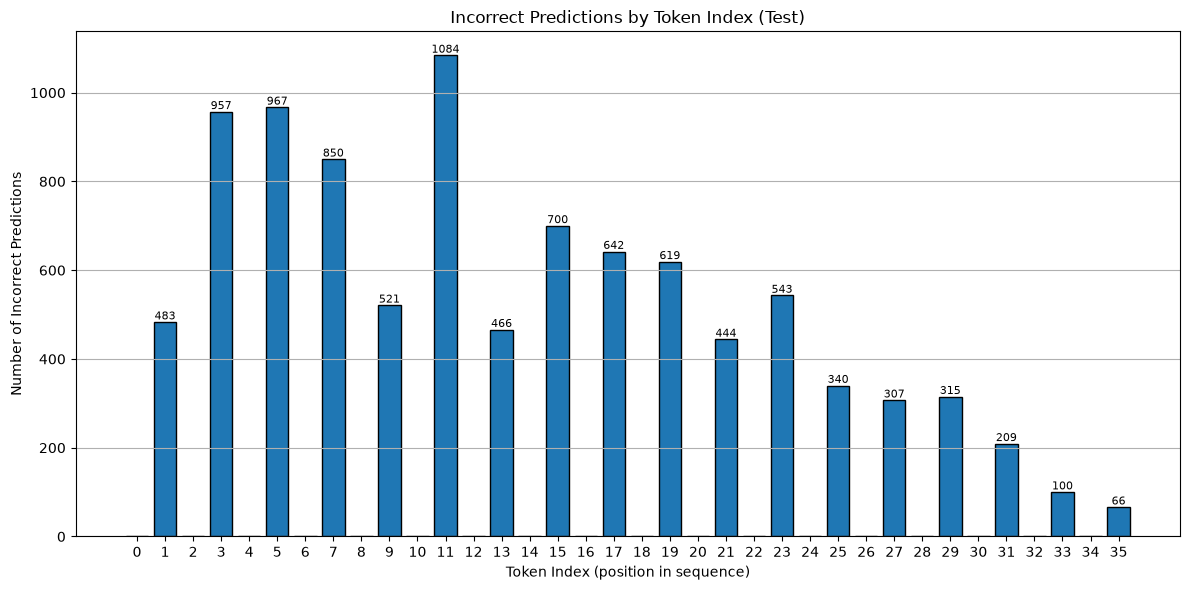

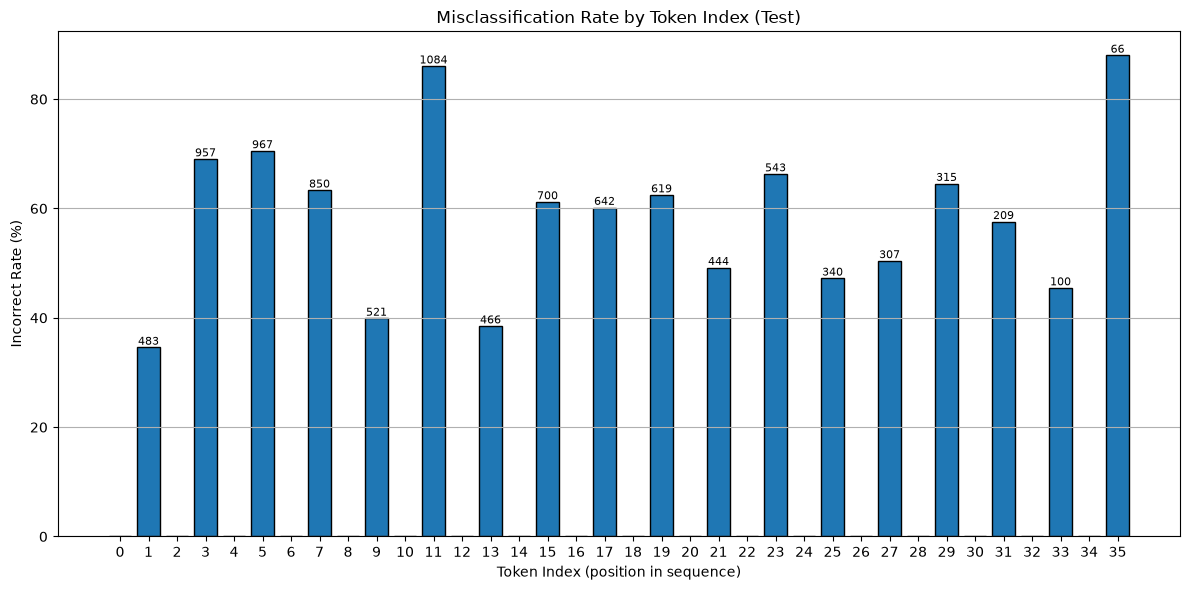

In [34]:
words = []
seq_accuracies = []
lengths = []
dataset_indices = []

total_by_length         = defaultdict(int)
misclassified_by_length = defaultdict(int)

test_tokens   = test_tokens.to(device1)
test_seq_acc  = getPredictions(model, test_tokens, test_targets, test_mask)

for i in range(len(test_tokens)):
    input_seq = test_tokens[i]
    word_str  = ' '.join([str(int(tok)) for tok in input_seq.tolist()])
    word_len  = (input_seq != 0).sum().item()   # no special token in the new format

    words.append(word_str)
    seq_accuracies.append(test_seq_acc[i].item())
    lengths.append(word_len)
    dataset_indices.append(i)

    total_by_length[word_len] += 1
    if test_seq_acc[i].item() < 1.0:
        misclassified_by_length[word_len] += 1

# Per-sequence misclassified list (used by the attention-head visualization below)
misclassified = [
    (words[i], lengths[i], seq_accuracies[i], dataset_indices[i])
    for i in range(len(words)) if seq_accuracies[i] < 1.0
]

print("\nRandom Sample of Misclassified Test Sequences:")
for word, length, acc, idx in random.sample(misclassified, min(20, len(misclassified))):
    print(f"Word: {word} | Length: {length} | Seq Acc: {acc:.3f} | Index: {idx}")

# Per-token-index error counts
test_incorrect, test_total = position_error_counts(model, test_tokens, test_targets, test_mask)
print("\nTest incorrect predictions per token index:")
print(test_incorrect.int().tolist())
print(f"Total incorrect positions: {int(test_incorrect.sum())} / {int(test_total.sum())} valid positions")

positions = list(range(len(test_incorrect)))
counts    = test_incorrect.int().tolist()

# Plot 1: Raw count of incorrect predictions at each token index
plt.figure(figsize=(12, 6))
bars = plt.bar(positions, counts, edgecolor='black')
for bar, c in zip(bars, counts):
    if c > 0:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 str(c), ha='center', va='bottom', fontsize=8)
plt.title("Incorrect Predictions by Token Index (Test)")
plt.xlabel("Token Index (position in sequence)")
plt.ylabel("Number of Incorrect Predictions")
plt.xticks(positions)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# Plot 2: Misclassification rate at each token index (relative to valid positions there)
percent = [100 * i / t if t > 0 else 0.0
           for i, t in zip(test_incorrect.tolist(), test_total.tolist())]
plt.figure(figsize=(12, 6))
bars = plt.bar(positions, percent, edgecolor='black')
for bar, c in zip(bars, counts):
    if c > 0:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 str(c), ha='center', va='bottom', fontsize=8)
plt.title("Misclassification Rate by Token Index (Test)")
plt.xlabel("Token Index (position in sequence)")
plt.ylabel("Incorrect Rate (%)")
plt.xticks(positions)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

### Other Graphs
- check on misclassified
- attention heads of random selection of misclassified train inputs

In [35]:
print(f"total word count: {sum(total_by_length.values())}")
print(f"total misclassified count: {sum(misclassified_by_length.values())}")

total word count: 1399
total misclassified count: 1393


In [33]:
# Prints 1 graph per attention head
# x: letters (keys attended to)
# y: letters (query giving attention to x axis)

# Make sure there are at least 4 items to sample from
sample_size = min(4, len(misclassified))

# Take random sample of misclassified items
sample = random.sample(misclassified, sample_size)

misclassified_index = [index for _, _, _, index in sample]
# NOTE: the big `cache` above was computed on train_tokens, but these indices point
# into the TEST set — so run the model on each chosen test word to get its own cache.
for mis_index in misclassified_index:
    chosenWord = test_tokens[mis_index].unsqueeze(0).to(device1)  # shape (1, 22)
    _, word_cache = getLogits(model, chosenWord, getCache=True)

    # Generate labeled tokens with position

    # ex: word len 22: str_tokens = [0,...,21]
    str_tokens = [f"{i}" for i, tok in enumerate(chosenWord[0])]

    # Visualize
    n_heads = model.cfg.n_heads
    n_layers = model.cfg.n_layers
    for layer in range(n_layers):
        for head in range(n_heads):
            # this word is batch entry 0 of its own single-word cache
            attn_single_head = word_cache["pattern", layer][0, head].detach().cpu()

            imshow(
                attn_single_head,
                x=str_tokens,
                y=str_tokens,
                xaxis="Key (Attended To)",
                yaxis="Query (Paying Attention)",
                title=f"Layer {layer} Head {head} Attention Pattern (for test word {mis_index})(Positional Tokens)"
            )

NameError: name 'misclassified' is not defined

In [34]:
import numpy as np
import plotly.graph_objects as go
import torch

# ---------------------------------------------------------------------------
# 1. Configuration & Region Definition
# ---------------------------------------------------------------------------
# We will use the test dataset to find out how the model generalizes
tokens_all = data["test_tokens"]
targets_all = data["test_targets"]
mask_all = data["test_mask"]

# FIX: Read checkpoints and epochs directly from the loaded cached_data dict
epochs = cached_data["checkpoint_epochs"]
checkpoints = cached_data["checkpoints"]
num_words = tokens_all.shape[0]

# Standard 6-wedge arrangement for your group
REGIONS = torch.tensor([
    [0, 0, 0],  # Region 0
    [1, 0, 0],  # Region 1
    [1, 1, 0],  # Region 2
    [1, 1, 1],  # Region 3
    [0, 1, 1],  # Region 4
    [0, 0, 1]   # Region 5
], dtype=torch.float32)

def bitmask_to_region_index(tensor_batch):
    dist = torch.abs(tensor_batch.unsqueeze(-2) - REGIONS.to(tensor_batch.device)).sum(dim=-1)
    return torch.argmin(dist, dim=-1)

def cyclical_wedge_distance(region_a, region_b):
    diff = torch.abs(region_a - region_b)
    return torch.minimum(diff, 6 - diff)

# ---------------------------------------------------------------------------
# 2. Extract Last Non-Padding Index (Full String Descent Set)
# ---------------------------------------------------------------------------
# Find the index of the last valid letter for each word sequence
# mask_all is [num_words, seq_len] with 1s for valid tokens and 0s for padding
last_valid_indices = mask_all.sum(dim=-1) - 1 # Shape: [num_words]
word_indices = torch.arange(num_words, device=tokens_all.device)

# Grab the final target descent bitmask for each complete string
final_targets = targets_all[word_indices, last_valid_indices, :] # Shape: [num_words, 3]
target_regions = bitmask_to_region_index(final_targets) # Shape: [num_words]

# Array to store the dataset's average distance at each checkpoint epoch
avg_distances_per_epoch = []

print(f"Processing final-string descent sets for all {num_words} words across checkpoints...")

# ---------------------------------------------------------------------------
# 3. Compute Average Metric Across All Checkpoints
# ---------------------------------------------------------------------------
with torch.inference_mode():
    for cp_idx, state_dict in enumerate(checkpoints):
        model.load_state_dict(state_dict)
        
        model.reset_hooks()
        register_pad_mask_hook(model, data["test_attention_mask"])
        
        # Forward pass over the entire batch
        logits = model(tokens_all)
        preds = (logits > 0).float()
        
        # Extract the predictions at the final string boundaries
        final_preds = preds[word_indices, last_valid_indices, :] # Shape: [num_words, 3]
        pred_regions = bitmask_to_region_index(final_preds) # Shape: [num_words]
        
        # Calculate geometric distance (0 to 3) for every word
        wedge_dists = cyclical_wedge_distance(pred_regions, target_regions)
        
        # Compute the mean error across all words at this epoch
        mean_epoch_distance = wedge_dists.float().mean().item()
        avg_distances_per_epoch.append(mean_epoch_distance)

print("Calculation complete!")

# ---------------------------------------------------------------------------
# 4. Graph the Global Average Convergence Curve
# ---------------------------------------------------------------------------
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=epochs, 
    y=avg_distances_per_epoch,
    mode='lines+markers',
    line=dict(color='firebrick', width=3),
    marker=dict(size=6),
    name='Global Average Error'
))

fig.update_layout(
    title="Global Optimization: Average Cyclical Wedge Distance over Training",
    xaxis_title="Training Epoch",
    yaxis_title="Average Distance (Wedges Away From Target)",
    yaxis=dict(range=[0, 3.2], tickvals=[0, 1, 2, 3]), # Bound the metric range explicitly
    grid=dict(rows=1, columns=1),
    template="plotly_white"
)

fig.show()

Processing final-string descent sets for all 1399 words across checkpoints...
Calculation complete!


In [4]:
# ==============================================================================
# Comparative Attention Analysis: ABA Endings vs. Non-ABA Endings
# ==============================================================================

import torch
import numpy as np
import plotly.graph_objects as go

PAD_VAL = 3

# 1. Combine all dataset tokens
all_tokens = torch.cat([train_tokens, test_tokens], dim=0)  # Shape: [N, seq_len]

aba_indices = []
non_aba_indices = []
word_lengths = []  # Stores the index of the last non-padding token

for idx, seq in enumerate(all_tokens):
    valid = [t.item() for t in seq if t.item() != PAD_VAL]
    if len(valid) >= 3:
        last3 = valid[-3:]
        last_tok_idx = len(valid) - 1
        word_lengths.append(last_tok_idx)
        
        # Check 'aba' pattern: first == third AND first != second
        if last3[0] == last3[2] and last3[0] != last3[1]:
            aba_indices.append(idx)
        else:
            non_aba_indices.append(idx)

aba_tokens = all_tokens[aba_indices].to(device)
non_aba_tokens = all_tokens[non_aba_indices].to(device)

print(f"Total Sequences Analyzed: {len(all_tokens)}")
print(f"  - ABA Ending Words:     {len(aba_indices)}")
print(f"  - Non-ABA Ending Words: {len(non_aba_indices)}\n")

# 2. Run Forward Pass with Cache for Both Groups
model.eval()
with torch.no_grad():
    _, aba_cache = model.run_with_cache(aba_tokens)
    _, non_aba_cache = model.run_with_cache(non_aba_tokens)

n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads

# Function to compute average suffix attention % across a set of sequence indices
def compute_suffix_attention_pct(cache_obj, seq_indices):
    attn_stats = { (l, h): [] for l in range(n_layers) for h in range(n_heads) }
    
    for l in range(n_layers):
        # Attention tensor: [batch_size, n_heads, seq_len, seq_len]
        layer_attn = cache_obj[f"blocks.{l}.attn.hook_pattern"]
        
        for h in range(n_heads):
            for batch_i, global_idx in enumerate(seq_indices):
                last_idx = word_lengths[global_idx]
                q_attn = layer_attn[batch_i, h, last_idx, :]
                
                # Suffix vs Prefix sums
                suffix_attn = q_attn[last_idx - 2 : last_idx + 1].sum().item()
                prefix_attn = q_attn[0 : max(0, last_idx - 2)].sum().item()
                
                total_valid = suffix_attn + prefix_attn
                if total_valid > 0:
                    attn_stats[(l, h)].append((suffix_attn / total_valid) * 100)
                    
    # Return average per (layer, head)
    return { k: np.mean(v) for k, v in attn_stats.items() }

aba_suffix_pcts = compute_suffix_attention_pct(aba_cache, aba_indices)
non_aba_suffix_pcts = compute_suffix_attention_pct(non_aba_cache, non_aba_indices)

# 3. Print Detailed Comparison Breakdown
print(f"{'Layer/Head':<10} | {'ABA Suffix %':<15} | {'Non-ABA Suffix %':<16} | {'Difference':<12}")
print("-" * 60)

head_labels = []
aba_vals = []
non_aba_vals = []

for l in range(n_layers):
    for h in range(n_heads):
        label = f"L{l}H{h}"
        head_labels.append(label)
        
        a_val = aba_suffix_pcts[(l, h)]
        na_val = non_aba_suffix_pcts[(l, h)]
        diff = a_val - na_val
        
        aba_vals.append(a_val)
        non_aba_vals.append(na_val)
        
        print(f"{label:<10} | {a_val:6.2f}%         | {na_val:6.2f}%          | {diff:+6.2f}%")

# 4. Plot Side-by-Side Comparison
fig = go.Figure()

fig.add_trace(go.Bar(
    x=head_labels,
    y=aba_vals,
    name="ABA Suffix Words (e.g., 010, 121)",
    marker_color="#d95f02"
))

fig.add_trace(go.Bar(
    x=head_labels,
    y=non_aba_vals,
    name="Non-ABA Suffix Words (e.g., 012, 102)",
    marker_color="#7570b3"
))

fig.update_layout(
    title="Attention Focus on Suffix (Last 3 Word Tokens): ABA vs. Non-ABA Words",
    xaxis_title="Attention Layer & Head",
    yaxis_title="% Attention Paid to Suffix (Last 3 Tokens)",
    yaxis=dict(range=[0, 100]),
    barmode="group",
    template="plotly_white",
    height=500,
    width=900
)

fig.show()

Total Sequences Analyzed: 1998
  - ABA Ending Words:     103
  - Non-ABA Ending Words: 1895

Layer/Head | ABA Suffix %    | Non-ABA Suffix % | Difference  
------------------------------------------------------------
L0H0       |  14.70%         |  12.06%          |  +2.64%
L0H1       |  11.92%         |  10.46%          |  +1.46%
L0H2       |  12.56%         |  11.01%          |  +1.55%
L0H3       |  12.39%         |  10.43%          |  +1.96%
